In [27]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import texplot
import matplotlib.ticker as mticker

# Imports from freealg
import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot, plot_edges
from freealg.visualization._api_plot_util import _k_pow2_formatter

# Plotting options
plot_dir = './plots'
save_filename = 'diffusion'
latex = True

# Diffusion Model

Data's ESD replicates Fig 4 (right panel) of:

* [Why Diffusion Models Don’t Memorize: The Role of Implicit Dynamical Regularization in Training](https://openreview.net/pdf?id=BSZqpqgqM0)

The data is the matrix $\mathbf{U}$ in the above paper, here generated at the size $64K \times 64K$.

The input file loaded below (`Umatrix64k_eigs.npz`) contains a list of numpy arrays. Each array is the eigenvalues of a sumbatrix, ranging from the size $1K, 2K, 4K, \dots, 64K$.

Idx   Size   Repeat
---  -----   ------
0     1000       16
1     1414       11
2     2000        8
3     2828        5
4     4000        4
5     5656        2
6     8000        2
7    11313        1
8    16000        1
9    22627        1
10   32000        1
11   45254        1
12   64000        1

proc name: Intel(R) Xeon(R) Gold 6126 CPU @ 2.60GHz
num proc:  48
date:      2026-04-14 03:26:08 PDT



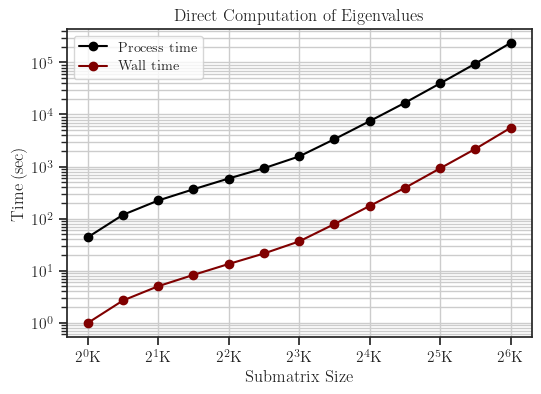

In [2]:
# Load input file
# filename = 'Umatrix64k_eigs_old.npz'
filename = 'Umatrix64k_eigs.npz'                      # float32
filename = 'Umatrix64k_eigs_half.npz'                 # float32
# filename = 'Umatrix64kf3.2n100d0.01t_eigs.npz'          # float64
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, filename), allow_pickle=True)
out = data['out'].item()

# Extract variables
sizes = out['sizes']                 # List of sizes of the submatrices
repeats = out['repeats']             # Repeats of sampling
eigs_repeated = out['eigs']          # List of eigenvalues per each submatrix
eigs = out['eigs']                   # List of eigenvalues per each submatrix
wall_times = out['wall_times']       # List of wall times taken to compute eigenvalues
proc_times = out['proc_times']       # List of CPU process times taken to compute eigenvalues
n, p = out['shape']                  # Dimension of the original matrix (largest matrix)
proc_name = out['proc_name']
num_proc = out['num_proc']
date = out['date']

# concatenate all repeats
max_repeat = 2
eigs = [None] * len(eigs_repeated)
for i in range(len(eigs_repeated)):
    rep_size = min(eigs_repeated[i].shape[0], max_repeat)
    eigs[i] = eigs_repeated[i][:rep_size, :].ravel()

# Sizes of submatrices
print('Idx   Size   Repeat')
print('---  -----   ------')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}  {repeats[i]:>7d}')
print('')
print(f'proc name: {proc_name}')
print(f'num proc:  {num_proc}')
print(f'date:      {date}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

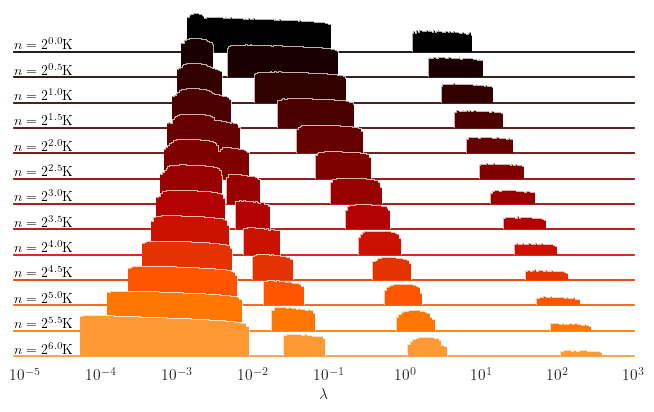

In [3]:
ridgeplot(sizes, eigs=eigs, log=True, scaley=False, hspace=-0.4,
          text_side='left', xlim=(7e-6, 1e3), figsize=(8, 4.5),
          # label_mode='pow-int',
          label_mode='pow-dec',
          latex=latex, title='',
          save=False, nbins=200)

# Fit Spectral Curve

In [3]:
# Index to choose the initial sub-matrix size
# start_idx = 2  # TEST
start_idx = 4

# Detect support from histogram
print('\n------------------------------------------')
print('Support (detected from histogram):')
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True,
                      print_info=True)

# Stieltjes options (Homotopy)
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 20,
    anchor_mode = 'empirical',
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 10,
    anchor_ratio = 1,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.05,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes (Plemelj)
inv_stieltjes_opt = dict(
    delta = 1e-6,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 4,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'chebfit',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'small_delta',  # 'uniform, small_delta
)

# Smaller delta lowers the density baseline curve 1/x^2.
af = AlgebraicForm(eigs[start_idx],
                   support=support,
                   n=sizes[start_idx],
                   log=True,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

# We use deg_z = 1 since we guess the data is closely related to free Levy
# model, where deg_z is always 1. We also set _deg_m = 5 to have the capacity
# of representing 4 bulks once decompressed.
print('\n------------------------------------------')

# Combinations that work
# deg_m, deg_z = 8, 5
# deg_m, deg_z = 10, 5
# deg_m, deg_z = 9, 5
# deg_m, deg_z = 8, 4
# deg_m, deg_z = 7, 3
# deg_m, deg_z = 6, 6
# deg_m, deg_z = 6, 3
# deg_m, deg_z = 5, 5
deg_m, deg_z = 7, 5  # VERY GOOG

deg_mu = 4
mu = numpy.zeros((deg_mu+1, ), dtype=float)
mu[0] = 1.0
for i in range(1, mu.size):
    if i == 1:
        mu[i] = numpy.mean(af.eig)
    else:
        mu[i] = numpy.mean(af.eig**i)

coeffs = af.fit(
    deg_m, deg_z,
    reg=0,
    r_min=1.8, r_max=2.2, n_r=5,
    y_scale=1.0, gamma=1.0,
    n_samples=4096 // 2,
    cut_eps=0.01,
    normalize=True,
    triangular=(None, None),
    mu=mu,
    mu_reg=None, verbose=True, plot=False)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, '
#           f'weight: {100.0*atom[1]:>4.1f}%')


------------------------------------------
Support (detected from histogram):
| bulk 1 | interval: (  0.00072,   0.00646) | center:   0.00215 |  mass: 80.00% |
| bulk 2 | interval: (  0.03802,   0.27663) | center:   0.10255 |  mass: 17.50% |
| bulk 3 | interval: (  6.25733,  27.72341) | center:  13.17097 |  mass:  2.50% |
mass(x) ~ 0.07001 * x^(-0.3977)

------------------------------------------
fit residual max  : 3.0440e-04
fit residual 99.9%: 3.0366e-04

Coefficients (real)
+0.92130239 +0.10706747 +0.00214967 -0.00001485 +0.00000003 -0.00000000 -0.00000000 +0.00000000 
+0.03332729 +2.76064319 +0.30842927 +0.00556960 -0.00002466 +0.00000002 +0.00000000 +0.00000000 
-0.03210949 -0.06130734 +2.06667499 +0.21817359 +0.00373171 -0.00000775 -0.00000000 -0.00000000 
+0.01309749 -0.05848331 -0.09973933 +0.20675003 -0.00190725 +0.00000530 -0.00000001 +0.00000000 
+0.00016335 +0.02869172 -0.02644055 -0.00306868 +0.00003748 -0.00000012 +0.00000000 -0.00000000 
+0.00000000 +0.00016335 +0.0156

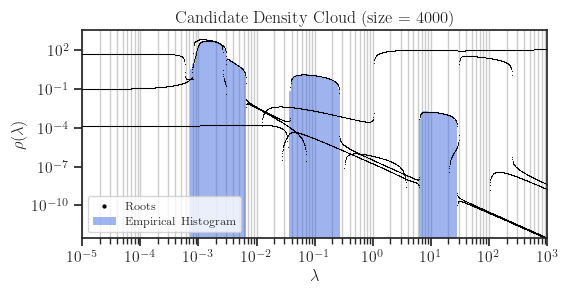

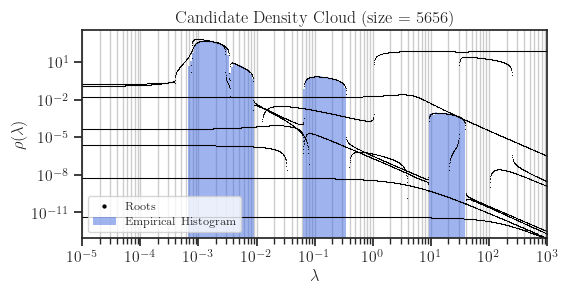

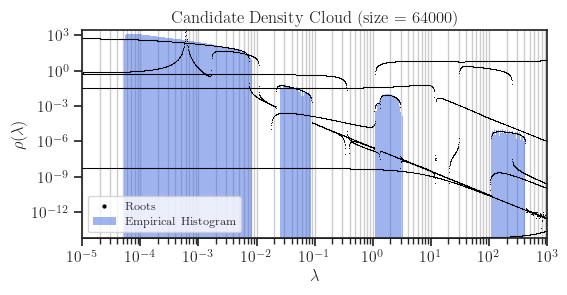

In [5]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min = 1e-5
x_max = 1e3
x_highres = numpy.geomspace(x_min, x_max, 2000)

# for idx in range(start_idx, sizes.size):
for idx in [start_idx, start_idx+1, sizes.size-1]:
    af.candidates(
        size=sizes[idx],
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6, latex=latex)

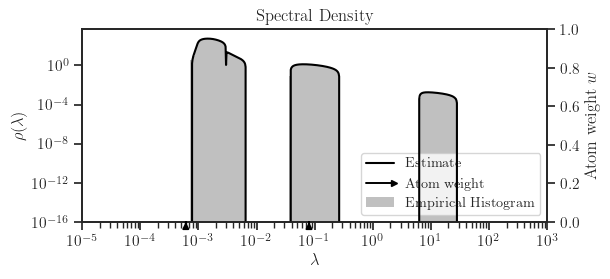


Mass: 0.99899708


In [22]:
# Plot density
x_min = 1e-5
x_max = 1e3
x0 = numpy.geomspace(x_min, x_max, 1000)
rho0 = af.density(x0, plot=True, latex=latex)

# Check mass (at start size)
print('')
mass = numpy.trapz(rho0, x0)
print(f'Mass: {mass:0.8f}')

Support (estimated from polynomial):
	Interval 1: (   0.0009,    0.0063)
	Interval 2: (   0.0383,    0.2653)
	Interval 3: (   6.2467,   28.4951)


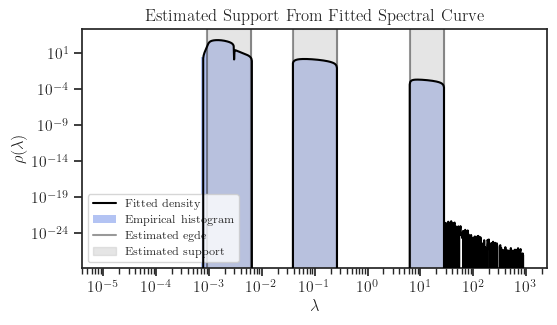

In [42]:
print('Support (estimated from polynomial):')

est_supp = af.support(refine=False, resplit_density=4, merge_threshold=0.1)

for i, supp in enumerate(est_supp):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

with texplot.theme(use_latex=latex):
    alpha = 0.4
    fig, ax = plt.subplots(figsize=(6, 3.1))
    ax.plot(x0, rho0, color='black', zorder=10, label='Fitted density')
    
    bins = numpy.geomspace(
        numpy.min(eigs[start_idx]), numpy.max(eigs[start_idx]), 150)
    ax.hist(eigs[start_idx], bins, density=True,color='royalblue',
            alpha=0.4, zorder=1, edgecolor='none',
            label='Empirical histogram')
    
    for i in range(len(est_supp)):
        label = 'Estimated egde' if i == 0 else ''
        ax.axvline(est_supp[i][0], linestyle='-', color='black', alpha=alpha, label=label)
        ax.axvline(est_supp[i][1], linestyle='-', color='black', alpha=alpha)
    
        label = 'Estimated support' if i == 0 else ''
        ax.axvspan(est_supp[i][0], est_supp[i][1], color='silver', alpha=alpha, label=label)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    # ax.set_xlim([x[0], x[-1]])
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\rho(\lambda)$')
    ax.legend(fontsize='x-small', loc='lower left')
    ax.set_title('Estimated Support From Fitted Spectral Curve')
    plt.show()

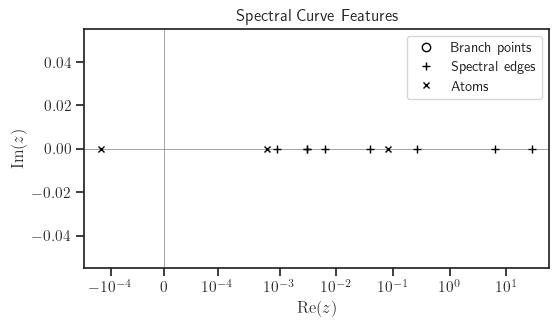


i   Branch Points        Spectral Edge
--  -------------------  -------------


In [10]:
# Branch points
bp = af.branch_points(tol=1e-16, real_tol=1e-16, plot=True, latex=latex)

# A branch point on real axis is a candidate to also be a spectral edge.
# Those with near zero imaginary part are flagged as maybe a spectral edge.
print('\ni   Branch Points        Spectral Edge')
print('--  -------------------  -------------')
for i in range(bp.size):
    print(f'{i+1}   {bp[i].real:>+8.4f}{bp[i].imag:>+5.3e}i', end='  ')
    if numpy.abs(bp[i].imag) < 1e-14:
        print('Maybe')
    else:
        print('No')

# Free Decompression

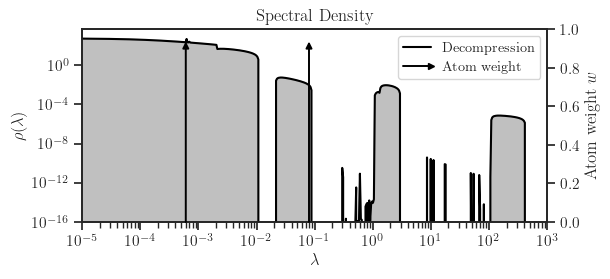

In [36]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 500)

newton_opt = dict(
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x, atoms = af.decompress(
    fd_sizes, x=x, method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

In [44]:
rho_clean = numpy.copy(rho)
rho_clean = numpy.abs(rho_clean)

for i in range(rho_clean.shape[0]):
    # Trim left edge that follows Tracy-Widom or extreme universaility
    # We will plot left edge later below
    left = x < numpy.nanmin(eigs[start_idx+i])
    rho_clean[i, left] = 0.0 # numpy.nan

    # Dnsity below Poisson kenrel delta floor is technically zero
    poisson = (af.delta / numpy.pi) / (x**2 + af.delta**2)
    small = rho_clean[i] < poisson
    rho_clean[i, small] = 0.0

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-flow.pdf".


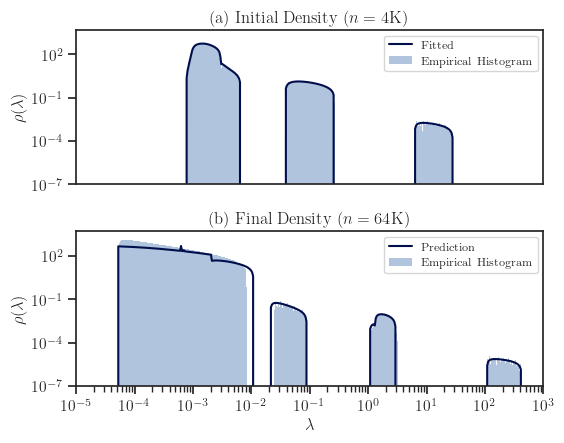

In [45]:
%matplotlib inline
plot_flow(fd_sizes, x, rho_clean, eigs[start_idx], eigs[end_idx], delta=af.delta,
          figsize=(5.8, 4.6),
          xlim=(1e-5, 1e3),
          ylim=(1e-7, 5e3),
          nbins=(350, 450),
          share_ax=True,
          layout='vertical',
          title='Free Decompression',
          plot_middle=False,
          plot_floor=False,
          cmap=plt.cm.ocean,
          c_range=(0.3, 0.3001),
          hist_color='lightsteelblue',
          label_mode='pow-int',
          log=True,
          latex=latex,
          save=join(plot_dir, save_filename + '-flow.pdf'))

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-ridge.pdf".


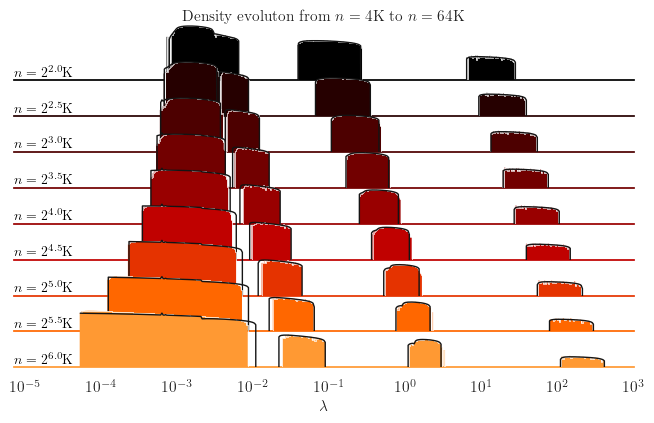

In [46]:
mask = x > numpy.min(eigs[end_idx])
gray = 0.08

%matplotlib inline
ridgeplot(sizes[start_idx:end_idx+1], x=x[mask], rho=rho_clean[:, mask],
          eigs=eigs[start_idx:end_idx+1],
          log=True, ylim=(1e-7, 5e3), scaley=False, hspace=-0.4,
          cmap=plt.cm.gist_heat, c_range=(0, 0.8),
          rho_color=(gray, gray, gray),
          text_side='left', xlim=(7e-6, 1e3), figsize=(8, 4.5),
          # label_mode='pow-int',
          label_mode='pow-dec',
          latex=latex, nbins=395,
          title=r'Density evoluton from $n=4$K to $n=64$K',
          save=join(plot_dir, save_filename + '-ridge.pdf'))

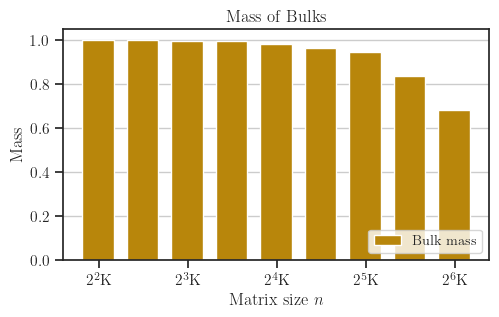

In [40]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, latex=latex,
          save=False)

# DEBUG

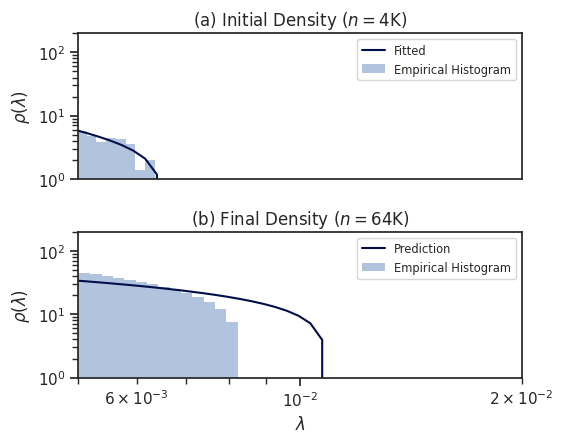

In [7]:
%matplotlib inline
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], delta=af.delta,
          figsize=(5.8, 4.6),
          xlim=(5e-3, 2e-2),
          ylim=(1e0, 2e2),
          nbins=(350, 450),
          share_ax=True,
          layout='vertical',
          title='Free Decompression',
          plot_middle=False,
          plot_floor=False,
          cmap=plt.cm.ocean,
          c_range=(0.3, 0.3001),
          hist_color='lightsteelblue',
          label_mode='pow-int',
          log=True,
          latex=False,
          save=False)

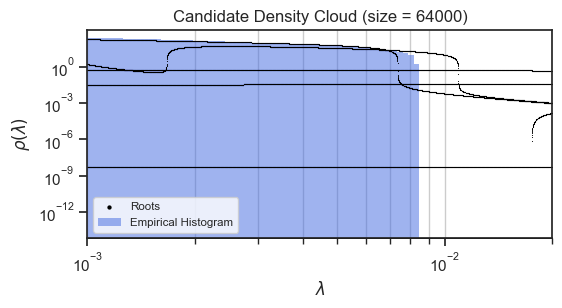

In [106]:
x_min = 1e-3
x_max = 2e-2
x_highres = numpy.geomspace(x_min, x_max, 5000)
idx = end_idx
af.candidates(
        size=sizes[idx],
        x=x_highres,
        eig=eigs[idx],
        delta=1e-6, markersize=0.6, latex=False)

# Track Candidate Roots

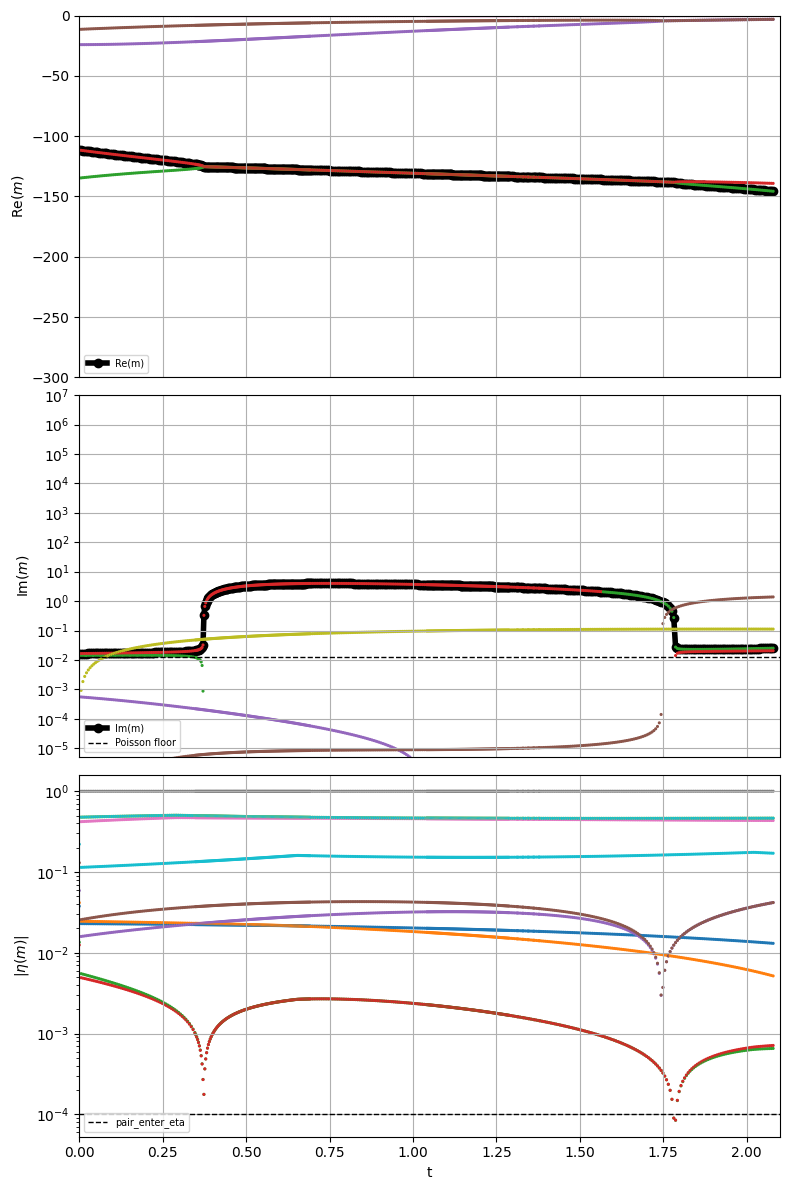

In [107]:
# %matplotlib qt
%matplotlib inline

_ = af.debug_decompress(
    fd_sizes[0:6+1],
    x=9e-3,
    # x=1e-4,
    min_n_times=500,
    newton_opt=newton_opt,
    # t_lim=[-0.05, 1.75],
    t_lim=[0.0, 2.1],
    re_lim=[-300, 0],
    # # im_lim=[1e0, 9e2],
    im_lim=[5e-6, 1e7],
)

# Edge

In [4]:
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

t_final = numpy.log(fd_sizes[-1] / fd_sizes[0])
t = numpy.linspace(0, t_final, 500)

# cusps, info = af.cusp(t, max_iter=1000, tol=1e-7, dedup_t_tol=1e-7,
#                       dedup_x_tol=1e-7, return_info=True)

# support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True)
est_supp = af.support(refine=False, resplit_density=4, merge_threshold=0.01)

complex_edges, real_merged_edges, active_k, cusps = af.edge(
    t, supp=est_supp, dt_max=0.01, max_iter=100, tol=1e-8)

print('Cusps:')
if len(cusps) > 0:
    for cusp in cusps:
        print(f'\tx: {cusp[0]:>0.3f}, t: {cusp[1]:>0.3f}')

Cusps:
	x: 1.111, t: 2.613


Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-edge.pdf".


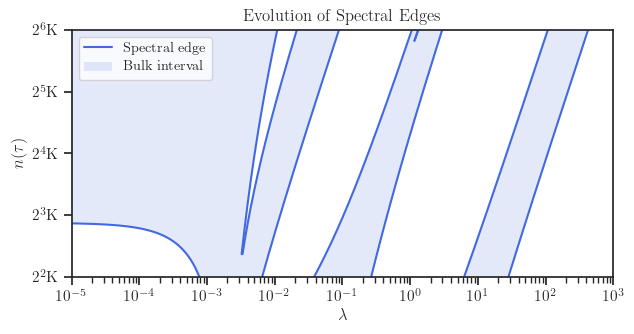

In [5]:
# Trim very close initial edges
# complex_edges_ = numpy.delete(complex_edges, [7, 8], axis=1)
# real_merged_edges_ = numpy.delete(real_merged_edges, [7, 8], axis=1)

plot_edges(t, complex_edges, real_merged_edges, cusps=None, sizes=fd_sizes,
           edge_color='royalblue', fill_color='royalblue', alpha=0.14,
           # edge_color='black', fill_color='gray', alpha=0.2,
           figsize=None, annotate=False, xlim=(1e-5, 1e3), log_x=True,
           log_y=True, flip_y=False,
           save=join(plot_dir, save_filename + '-edge.pdf'), latex=latex)

# Left Edge

In [6]:
# ==============
# fit shifted tw
# ==============

def fit_shifted_tw(sizes, min_eigs, sizes_eval, ngrid=2000):
    """
    Shifted Tracy-Widom lambda(n) = lambda(infty) + c n^{-2/3}.
    """
    
    sizes = numpy.asarray(sizes, float)
    min_eigs = numpy.asarray(min_eigs, float)
    sizes_eval = numpy.asarray(sizes_eval, float)

    z = sizes**(-2/3)
    agrid = numpy.linspace(0.0, float(numpy.min(min_eigs) * 0.999), ngrid)

    best_a_inf, best_C, best_mse = None, None, numpy.inf
    for a_inf in agrid:
        C = numpy.dot(z, min_eigs - a_inf) / numpy.dot(z, z)
        fit = a_inf + C * z
        mse = numpy.mean((min_eigs - fit)**2)
        if mse < best_mse:
            best_a_inf, best_C, best_mse = a_inf, C, mse

    left_edges_eval = best_a_inf + best_C * sizes_eval**(-2/3)
    
    return left_edges_eval, {"a_inf": best_a_inf, "C": best_C}

# ===========
# fit semilog
# ===========

def fit_semilog(sizes, min_eigs, sizes_eval):
    """
    Semilog lambda(n) = a + b*n.
    """
    
    sizes = numpy.asarray(sizes, float)
    min_eigs = numpy.asarray(min_eigs, float)
    sizes_eval = numpy.asarray(sizes_eval, float)

    m, b = numpy.polyfit(sizes, numpy.log(min_eigs), 1)
    left_edges_eval = numpy.exp(m * sizes_eval + b)
    
    return left_edges_eval, {"m": m, "b": b}

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-left-edge.pdf".


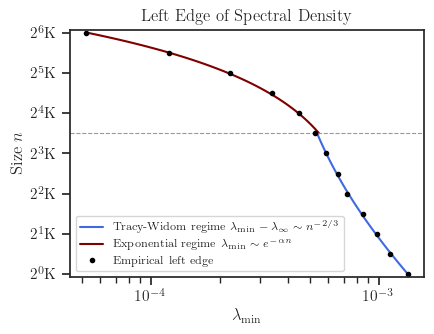

In [33]:
regime_idx = 7


min_eigs = numpy.zeros((len(eigs),))
for i in range(len(eigs)):
    min_eigs[i] = numpy.quantile(eigs[i], 0.00001)
    # support = freealg.supp(eigs[i], method='hist', tol=0, nbins=150, log=True)
    # min_eigs[i] = support[0][0]

# Tracy-Widom regime
tw_sizes = numpy.geomspace(sizes[0], sizes[regime_idx], 100)
tw_edge, tw_param = fit_shifted_tw(sizes[:regime_idx+1], min_eigs[:regime_idx+1], tw_sizes)

# Exponential regime
ll_sizes = numpy.geomspace(sizes[regime_idx], sizes[-1], 100)
ll_edge, ll_param = fit_semilog(sizes[regime_idx:], min_eigs[regime_idx:], ll_sizes)

with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(4.5, 3.5), ncols=1, sharey=False)

    ax.plot(tw_edge, tw_sizes, '-', color='royalblue',
            label=r'Tracy-Widom regime $\lambda_{\mathrm{min}} - \lambda_{\infty} \sim n^{-2/3}$')
    ax.plot(ll_edge, ll_sizes, '-', color='maroon',
            label=r'Exponential regime $\lambda_{\mathrm{min}} \sim e^{-\alpha n}$')
    ax.axhline(sizes[regime_idx], linestyle='--', color='0.6', linewidth=0.8)
    ax.plot(min_eigs, sizes, 'o', markersize=3, color='black',
            label='Empirical left edge')

    ax.set_ylim([sizes[0]/1.05, sizes[-1]*1.05])
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_xlabel(r'$\lambda_{\mathrm{min}}$')
    ax.set_ylabel(r'Size $n$')
    ax.set_title('Left Edge of Spectral Density')

    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    
    ax.legend(fontsize='x-small', loc='lower left')

    plt.tight_layout()
    # plt.show()

    full_save_filename = join(plot_dir, save_filename + '-left-edge.pdf')
    save_status = True
    texplot.show_or_save_plot(plt, default_filename=full_save_filename,
                                  transparent_background=True, dpi=200,
                                  show_and_save=save_status, verbose=True)

# Density and Left Edge

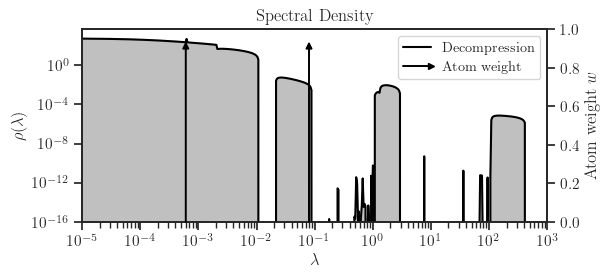

In [23]:
fd_sizes_plot = numpy.geomspace(sizes[start_idx], sizes[end_idx], t.size)

# x span of decompression
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 500)

newton_opt = dict(
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho_plot, x, atoms = af.decompress(
    fd_sizes_plot, x=x, method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

In [24]:
tw_idx = fd_sizes_plot <= sizes[regime_idx]
ll_idx = fd_sizes_plot > sizes[regime_idx]

tw_n = fd_sizes_plot[tw_idx]
ll_n = fd_sizes_plot[ll_idx]

left_edges = numpy.zeros_like(fd_sizes_plot)
left_edges[tw_idx] = tw_param['a_inf'] + tw_param['C'] * fd_sizes_plot[tw_idx]**(-2/3)
left_edges[ll_idx] = numpy.exp(ll_param['m'] * fd_sizes_plot[ll_idx] + ll_param['b'])

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-edge2.pdf".


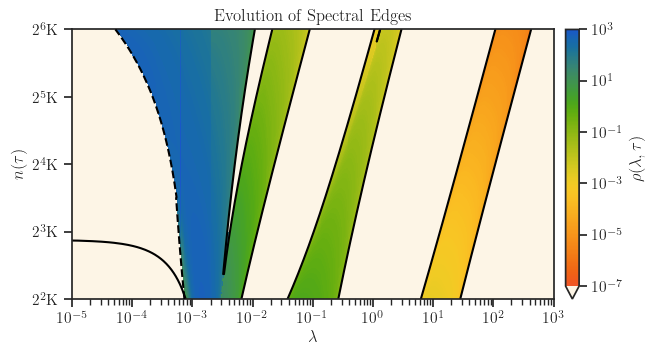

In [34]:
import colorcet as cc
from matplotlib.colors import LogNorm

t_ = sizes[start_idx] * numpy.exp(t)
xx, tt_ = numpy.meshgrid(x, t_)

poisson = (af.delta / numpy.pi) / (xx**2 + af.delta**2)
r = numpy.copy(rho_plot)
# r = numpy.abs(r)
# r[r < poisson] = numpy.nan
# r[r < poisson] = poisson[r < poisson]

# r[(r < 1e-7) & numpy.logical_not(near_cusp)] = numpy.nan
# r[(numpy.abs(r) < 1e-7)] = numpy.nan
r[r < 1e-7] = numpy.nan

# Repair nan points very close to cusp
near_cusp = (tt_ < 8e3) & (xx > 2e-3) & (xx < 5e-3)
repair = near_cusp & numpy.isnan(r)
r[repair] = 1e2 # poisson[repair]
r[(xx < left_edges[:, None])] = numpy.nan


# t_emp = numpy.log(sizes[start_idx:end_idx+1] / sizes[start_idx])
# t_emp = sizes[start_idx:end_idx+1]
# e_emp = min_eigs[start_idx:end_idx+1]

# cmap = plt.cm.YlOrRd
cmap = cc.cm.CET_R1_r
# cmap = cc.cm.CET_R4_r
cmap_trim = cmap.from_list('trimmed', cmap(numpy.linspace(0.2, 0.95, 256)))
bg_color = 'oldlace'
cmap_trim.set_under(bg_color)
# cmap_trim = cmap.from_list('trimmed', cmap(numpy.linspace(0.1, 0.7, 256)))

with texplot.theme(use_latex=True):
    fig, ax = plt.subplots(figsize=(7.5, 3.5))

    p = ax.pcolormesh(xx, tt_, r,
                      # norm=LogNorm(vmin=numpy.nanmin(r), vmax=numpy.nanmax(r)),
                      norm=LogNorm(vmin=1e-7, vmax=1e3),
                      cmap=cmap_trim, rasterized=True)
    
    ax.plot(real_merged_edges, t_, color='0.0')
    # ax.plot(e_emp, t_emp, '--', color='black', zorder=10)
    ax.plot(left_edges, t_, '--', color='black', zorder=10)
    
    ax.set_facecolor(bg_color)
    
    ax.set_ylim([t_[0], t_[-1]])
    ax.set_xscale('log')

    # cbar = plt.colorbar(p, pad=0.02)
    cbar = plt.colorbar(p, pad=0.02, extend='min')
    cbar.set_label(r'$\rho(\lambda, \tau)$')
    cbar.solids.set_rasterized(True)
    cbar.ax.minorticks_off()

    cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
    cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs='auto'))
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))

    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$n(\tau)$')
    ax.set_title('Evolution of Spectral Edges')
    # plt.show()

    fig.patch.set_alpha(0)

    full_save_filename = join(plot_dir, save_filename + '-edge2.pdf')
    save_status = True
    save_status = True
    texplot.show_or_save_plot(plt, default_filename=full_save_filename,
                                  transparent_background=False, dpi=200,
                                  show_and_save=save_status, verbose=True)